In [4]:
import pandas as pd
from io import StringIO


In [5]:
df = pd.read_csv('ht_eval.csv')
df = df[(df['batch_size'] == 32) & (df['input_size'] == 256)].sort_values(by='learning_rate')

In [ ]:
df['combination'].unique()
df['combination_name'] = df['learning_rate'].astype(str) + "-" + df['batch_size'].astype(str)

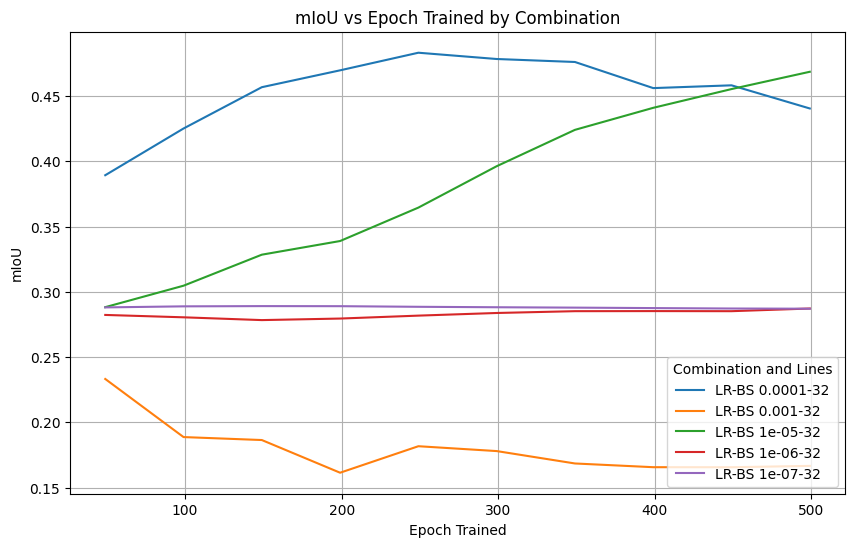

In [7]:
import matplotlib.pyplot as plt

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])
df = df[df['epoch_trained'] <= 500]


# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'LR-BS {combination}')

# Adicionando as linhas horizontais
# plt.axhline(y=0.6467, color='r', linestyle='--', label='coco')
# plt.axhline(y=0.5898, color='g', linestyle='--', label='sup')
# plt.axhline(y=0.6049, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Epoch Trained by Combination')
plt.xlabel('Epoch Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='lower right')
plt.grid(True)
plt.show()


[256 128  64 512]


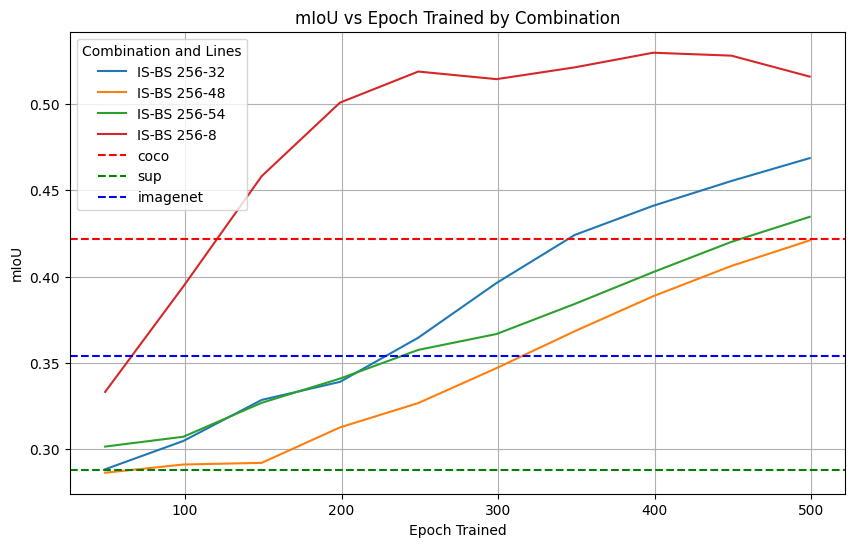

In [8]:
import matplotlib.pyplot as plt

df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] <= 500]


print(df['input_size'].unique())
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

df = df[df['learning_rate'] == 0.00001]
# df = df[df['batch_size'] == 8]
df = df[df['input_size'] == 256]

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'IS-BS {combination}')

# Adicionando as linhas horizontais
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Epoch Trained by Combination')
plt.xlabel('Epoch Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()

[256 128  64 512]


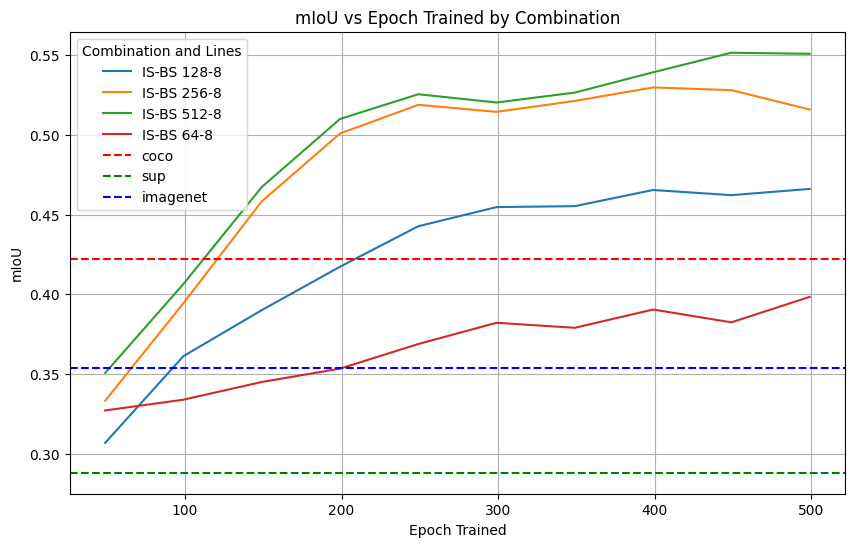

In [9]:
import matplotlib.pyplot as plt

df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] <= 500]


print(df['input_size'].unique())
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

df = df[df['learning_rate'] == 0.00001]
df = df[df['batch_size'] == 8]
# df = df[df['input_size'] == 256]

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'IS-BS {combination}')

# Adicionando as linhas horizontais
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Epoch Trained by Combination')
plt.xlabel('Epoch Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()

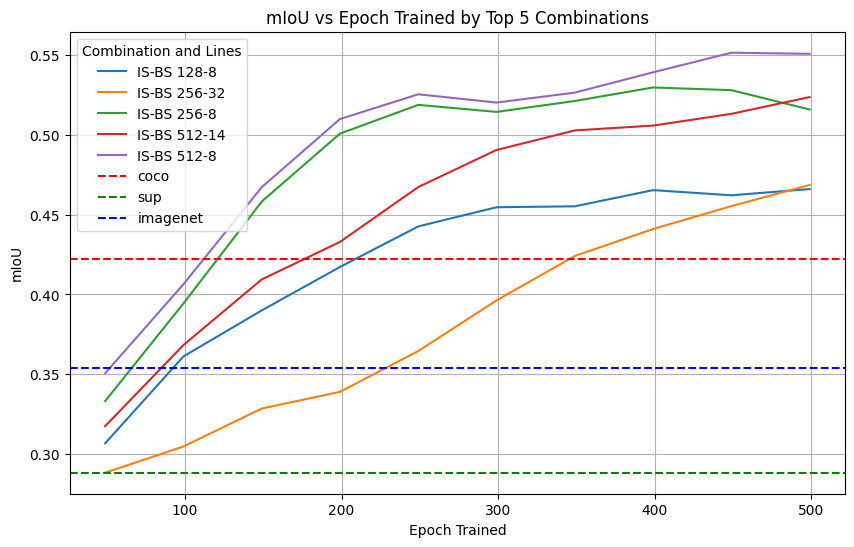

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] <= 500]

# Create combination name
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

# Filter by learning rate
df = df[df['learning_rate'] == 0.00001]

# Sort to ensure correct plotting
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Get final mIoU values at epoch 500
df_final = df[df['epoch_trained'] == 499]

# Find top 5 combinations by highest final mIoU
top5_combinations = df_final.sort_values(by='mIoU', ascending=False)['combination_name'].unique()[:5]

# Filter original dataframe to include only top 5
df_top5 = df[df['combination_name'].isin(top5_combinations)]

# Plotting
plt.figure(figsize=(10, 6)) 
for combination, group in df_top5.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'IS-BS {combination}')

# Add horizontal reference lines
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Final plot settings
plt.title('mIoU vs Epoch Trained by Top 5 Combinations')
plt.xlabel('Epoch Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()


[ 64 128 256 512]


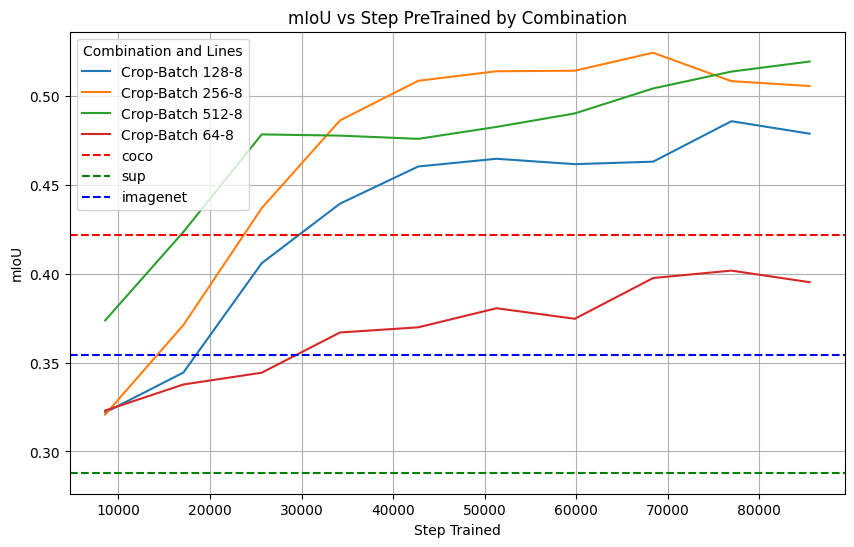

In [11]:
import matplotlib.pyplot as plt

df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] > 500]


print(df['input_size'].unique())
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

# df = df[df['learning_rate'] == 0.00001]
df = df[df['batch_size'] == 8]
# df = df[df['input_size'] == 256]

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'Crop-Batch {combination}')

# Adicionando as linhas horizontais
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Step PreTrained by Combination')
plt.xlabel('Step Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()

[ 64 128 256 512]


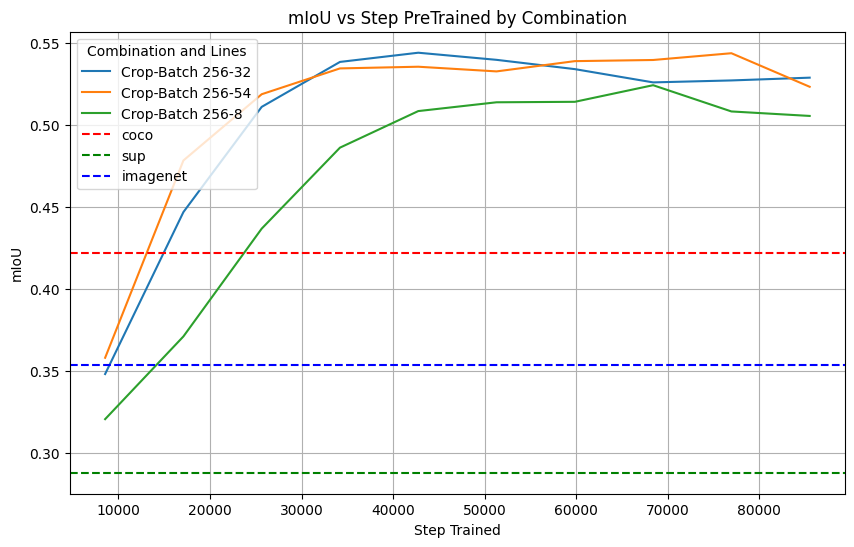

In [12]:
import matplotlib.pyplot as plt

df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] > 500]


print(df['input_size'].unique())
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

# df = df[df['learning_rate'] == 0.00001]
# df = df[df['batch_size'] == 8]
df = df[df['input_size'] == 256]

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'Crop-Batch {combination}')

# Adicionando as linhas horizontais
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Step PreTrained by Combination')
plt.xlabel('Step Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()

In [13]:
df = df.sort_values(by='mIoU', ascending=False)
df

,model_name,repetition,combination,pretrain_data,input_size,batch_size,epochs,learning_rate,epoch_trained,metrics_file,acc,f1_weighted,mIoU,combination_name
287,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,42750,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.800633,0.795487,0.544283,256-32
292,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,76950,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.812965,0.808037,0.543975,256-54
281,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,51300,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.805179,0.799993,0.539939,256-32
294,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,68400,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.812250,0.806373,0.539845,256-54
296,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,59850,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.813720,0.808551,0.539148,256-54
280,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,34200,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.795975,0.791860,0.538669,256-32
297,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,42750,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.805002,0.798942,0.535737,256-54
293,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,34200,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.795352,0.788811,0.534711,256-54
286,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,59850,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.809486,0.804035,0.534274,256-32
290,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,51300,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.811272,0.805023,0.532885,256-54


[ 64 128 256 512]


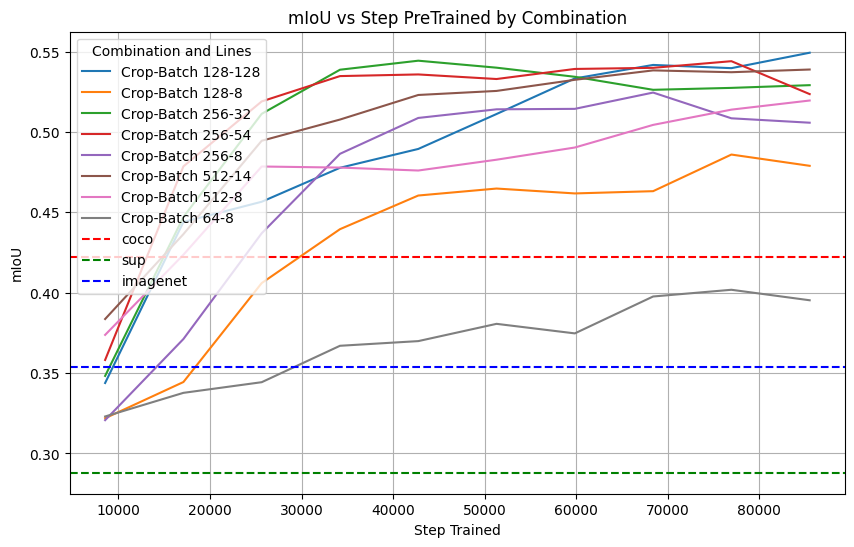

In [14]:
import matplotlib.pyplot as plt

df = pd.read_csv('ht_eval.csv')
df = df[df['epoch_trained'] > 500]


print(df['input_size'].unique())
df['combination_name'] = df['input_size'].astype(str) + "-" + df['batch_size'].astype(str)

# df = df[df['learning_rate'] == 0.00001]
# df = df[df['batch_size'] == 8]
# df = df[df['input_size'] == 256]

# Ordenando o DataFrame pelo eixo x (epoch_trained)
df = df.sort_values(by=['combination_name', 'epoch_trained'])

# Plotando o gráfico principal com as linhas horizontais
plt.figure(figsize=(10, 6)) 
for combination, group in df.groupby('combination_name'):
    plt.plot(group['epoch_trained'], group['mIoU'], label=f'Crop-Batch {combination}')

# Adicionando as linhas horizontais
plt.axhline(y=0.422, color='r', linestyle='--', label='coco')
plt.axhline(y=0.288, color='g', linestyle='--', label='sup')
plt.axhline(y=0.354, color='b', linestyle='--', label='imagenet')

# Configurações do gráfico
plt.title('mIoU vs Step PreTrained by Combination')
plt.xlabel('Step Trained')
plt.ylabel('mIoU')
plt.legend(title='Combination and Lines', loc='upper left')
plt.grid(True)
plt.show()

In [15]:
df = df.sort_values(by='mIoU', ascending=False)
df

,model_name,repetition,combination,pretrain_data,input_size,batch_size,epochs,learning_rate,epoch_trained,metrics_file,acc,f1_weighted,mIoU,combination_name
274,finetune_V6_pretrain_seam_ai_In128_B128_E85500...,6,45,seam_ai,128,128,85500,0.00001,85500,ht_logs/test_01/45/finetune_V6_pretrain_seam_a...,0.799455,0.795128,0.549243,128-128
287,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,42750,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.800633,0.795487,0.544283,256-32
292,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,76950,ht_logs/test_01/47/finetune_V6_pretrain_seam_a...,0.812965,0.808037,0.543975,256-54
277,finetune_V6_pretrain_seam_ai_In128_B128_E85500...,6,45,seam_ai,128,128,85500,0.00001,68400,ht_logs/test_01/45/finetune_V6_pretrain_seam_a...,0.799168,0.796173,0.541649,128-128
281,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,51300,ht_logs/test_01/46/finetune_V6_pretrain_seam_a...,0.805179,0.799993,0.539939,256-32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,finetune_V6_pretrain_seam_ai_In128_B128_E85500...,6,45,seam_ai,128,128,85500,0.00001,8550,ht_logs/test_01/45/finetune_V6_pretrain_seam_a...,0.671384,0.675896,0.343807,128-128
228,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,17100,ht_logs/test_01/40/finetune_V6_pretrain_seam_a...,0.672874,0.683143,0.337681,64-8
227,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,8550,ht_logs/test_01/40/finetune_V6_pretrain_seam_a...,0.658030,0.667295,0.322983,64-8
238,finetune_V6_pretrain_seam_ai_In128_B8_E85500_l...,6,41,seam_ai,128,8,85500,0.00001,8550,ht_logs/test_01/41/finetune_V6_pretrain_seam_a...,0.666164,0.679212,0.321900,128-8


In [16]:
data = """
learning_rate	batch_size	input_size	repetition	combination
1,00E-04	32	256	0	0
2,00E-04	32	256	3	1
1,00E-05	32	256	1	2
2,00E-05	32	256	2	3
1,00E-03	32	256	4	4
2,00E-03	32	256	1	5
1,00E-04	48	256	2	6
1,00E-04	54	256	3	7
"""

In [17]:

data = data.replace(",", ".")
combination_df = pd.read_csv(StringIO(data), sep="\t")
combination_df

,learning_rate,batch_size,input_size,repetition,combination
0,0.00010,32,256,0,0
1,0.00020,32,256,3,1
2,0.00001,32,256,1,2
3,0.00002,32,256,2,3
4,0.00100,32,256,4,4
5,0.00200,32,256,1,5
6,0.00010,48,256,2,6
7,0.00010,54,256,3,7


In [18]:
df_freeze = pd.read_csv('ht_eval_freeze.csv')
df = pd.read_csv('ht_eval.csv')
df_freeze.rename(columns={'acc': 'freeze_acc', 'f1_weighted': 'freeze_f1_weighted', 'mIoU': 'freeze_mIoU'}, inplace=True)
df_merged = df_freeze.merge(df[['combination', 'epoch_trained', 'mIoU', 'f1_weighted', 'acc']], 
                            on=['combination', 'epoch_trained'], how='left')

In [19]:
df_merged

,model_name,repetition,combination,pretrain_data,input_size,batch_size,epochs,learning_rate,epoch_trained,metrics_file,freeze_acc,freeze_f1_weighted,freeze_mIoU,mIoU,f1_weighted,acc
0,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,85500,ht_logs/test_03_freeze/40/finetune_V6_pretrain...,0.875990,0.877027,0.599076,0.395267,0.735776,0.729775
1,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,59850,ht_logs/test_03_freeze/40/finetune_V6_pretrain...,0.861698,0.864441,0.581541,0.374666,0.710404,0.705891
2,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,76950,ht_logs/test_03_freeze/40/finetune_V6_pretrain...,0.867972,0.867496,0.591803,0.401797,0.709284,0.712808
3,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,34200,ht_logs/test_03_freeze/40/finetune_V6_pretrain...,0.863215,0.864304,0.583081,0.366959,0.683979,0.682907
4,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,42750,ht_logs/test_03_freeze/40/finetune_V6_pretrain...,0.873579,0.873363,0.614203,0.369863,0.687885,0.687195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,17100,ht_logs/test_03_freeze/47/finetune_V6_pretrain...,0.878355,0.877687,0.638467,0.478535,0.757835,0.758063
76,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,59850,ht_logs/test_03_freeze/47/finetune_V6_pretrain...,0.902702,0.904727,0.649438,0.539148,0.808551,0.813720
77,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,42750,ht_logs/test_03_freeze/47/finetune_V6_pretrain...,0.890593,0.892477,0.638506,0.535737,0.798942,0.805002
78,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,25650,ht_logs/test_03_freeze/47/finetune_V6_pretrain...,0.890881,0.891632,0.646846,0.518955,0.773130,0.779541


In [20]:
df_merged['filtered_name'] = df_merged['model_name'].str.extract(r'finetune_(.*?)_step')
df_merged['metrics_file'] = "logs_aux/6/" + df_merged['filtered_name'] + '/seam_ai/' + df_merged['filtered_name'] + '/seam_ai/metrics.csv'

In [21]:
df_linear_unfreeze = pd.read_csv('ht_eval_unfreeze.csv')
df_linear_unfreeze.rename(columns={'acc': 'unfreeze_acc', 'f1_weighted': 'unfreeze_f1_weighted', 'mIoU': 'unfreeze_mIoU'}, inplace=True)
df_merged = df_linear_unfreeze.merge(df_merged[['combination', 'epoch_trained', 'mIoU', 'f1_weighted', 'acc', 'freeze_mIoU', 'freeze_f1_weighted', 'freeze_acc', 'metrics_file']], 
                            on=['combination', 'epoch_trained'], how='left')

In [22]:
df_merged

,model_name,repetition,combination,pretrain_data,input_size,batch_size,epochs,learning_rate,epoch_trained,metrics_file_x,unfreeze_acc,unfreeze_f1_weighted,unfreeze_mIoU,mIoU,f1_weighted,acc,freeze_mIoU,freeze_f1_weighted,freeze_acc,metrics_file_y
0,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,85500,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.922090,0.921617,0.694348,0.395267,0.735776,0.729775,0.599076,0.877027,0.875990,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
1,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,59850,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.898329,0.896714,0.677950,0.374666,0.710404,0.705891,0.581541,0.864441,0.861698,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
2,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,76950,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.913167,0.911852,0.715789,0.401797,0.709284,0.712808,0.591803,0.867496,0.867972,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
3,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,34200,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.920695,0.919833,0.715644,0.366959,0.683979,0.682907,0.583081,0.864304,0.863215,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
4,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,42750,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.918130,0.918552,0.706009,0.369863,0.687885,0.687195,0.614203,0.873363,0.873579,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,17100,ht_logs/test_02_unfreeze_rerun/47/finetune_V6_...,0.911800,0.911434,0.700707,0.478535,0.757835,0.758063,0.638467,0.877687,0.878355,logs_aux/6/V6_pretrain_seam_ai_In256_B54_E8550...
76,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,59850,ht_logs/test_02_unfreeze_rerun/47/finetune_V6_...,0.911458,0.910087,0.701647,0.539148,0.808551,0.813720,0.649438,0.904727,0.902702,logs_aux/6/V6_pretrain_seam_ai_In256_B54_E8550...
77,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,42750,ht_logs/test_02_unfreeze_rerun/47/finetune_V6_...,0.911514,0.908980,0.713675,0.535737,0.798942,0.805002,0.638506,0.892477,0.890593,logs_aux/6/V6_pretrain_seam_ai_In256_B54_E8550...
78,finetune_V6_pretrain_seam_ai_In256_B54_E85500_...,6,47,seam_ai,256,54,85500,0.00001,25650,ht_logs/test_02_unfreeze_rerun/47/finetune_V6_...,0.898939,0.896023,0.671291,0.518955,0.773130,0.779541,0.646846,0.891632,0.890881,logs_aux/6/V6_pretrain_seam_ai_In256_B54_E8550...


In [23]:
df_merged.sort_values(by='unfreeze_mIoU', ascending=False).head()


,model_name,repetition,combination,pretrain_data,input_size,batch_size,epochs,learning_rate,epoch_trained,metrics_file_x,unfreeze_acc,unfreeze_f1_weighted,unfreeze_mIoU,mIoU,f1_weighted,acc,freeze_mIoU,freeze_f1_weighted,freeze_acc,metrics_file_y
28,finetune_V6_pretrain_seam_ai_In256_B8_E85500_l...,6,42,seam_ai,256,8,85500,0.00001,68400,ht_logs/test_02_unfreeze_rerun/42/finetune_V6_...,0.918098,0.916591,0.729340,0.524465,0.784258,0.790791,0.665367,0.899710,0.900999,logs_aux/6/V6_pretrain_seam_ai_In256_B8_E85500...
5,finetune_V6_pretrain_seam_ai_In64_B8_E85500_lr...,6,40,seam_ai,64,8,85500,0.00001,25650,ht_logs/test_02_unfreeze_rerun/40/finetune_V6_...,0.919230,0.918553,0.725483,0.344305,0.707920,0.693158,0.586263,0.856956,0.856489,logs_aux/6/V6_pretrain_seam_ai_In64_B8_E85500_...
19,finetune_V6_pretrain_seam_ai_In128_B8_E85500_l...,6,41,seam_ai,128,8,85500,0.00001,68400,ht_logs/test_02_unfreeze_rerun/41/finetune_V6_...,0.916450,0.915575,0.723076,0.463123,0.753144,0.758934,0.659044,0.889711,0.889882,logs_aux/6/V6_pretrain_seam_ai_In128_B8_E85500...
69,finetune_V6_pretrain_seam_ai_In256_B32_E85500_...,6,46,seam_ai,256,32,85500,0.00001,68400,ht_logs/test_02_unfreeze_rerun/46/finetune_V6_...,0.923760,0.923325,0.721232,0.526178,0.802711,0.808019,0.670840,0.909527,0.906291,logs_aux/6/V6_pretrain_seam_ai_In256_B32_E8550...
15,finetune_V6_pretrain_seam_ai_In128_B8_E85500_l...,6,41,seam_ai,128,8,85500,0.00001,42750,ht_logs/test_02_unfreeze_rerun/41/finetune_V6_...,0.924740,0.924193,0.720663,0.460419,0.751812,0.751081,0.606600,0.875240,0.874498,logs_aux/6/V6_pretrain_seam_ai_In128_B8_E85500...


Combination: 64-8
Max mIoU: 0.4018
Max Freeze mIoU: 0.6142


/tmp/ipykernel_2926646/2750021850.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, pd.DataFrame([max_values])], ignore_index=True)


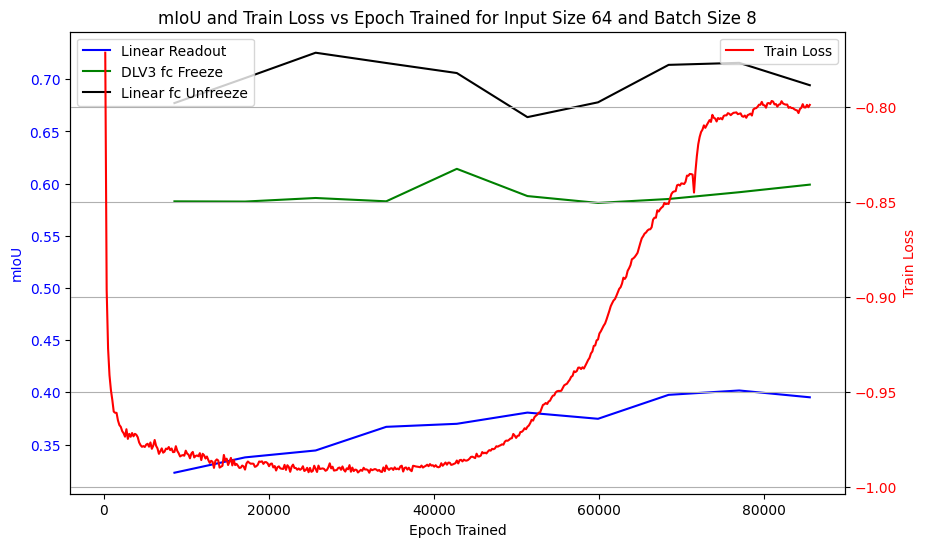

Combination: 128-8
Max mIoU: 0.4859
Max Freeze mIoU: 0.6730


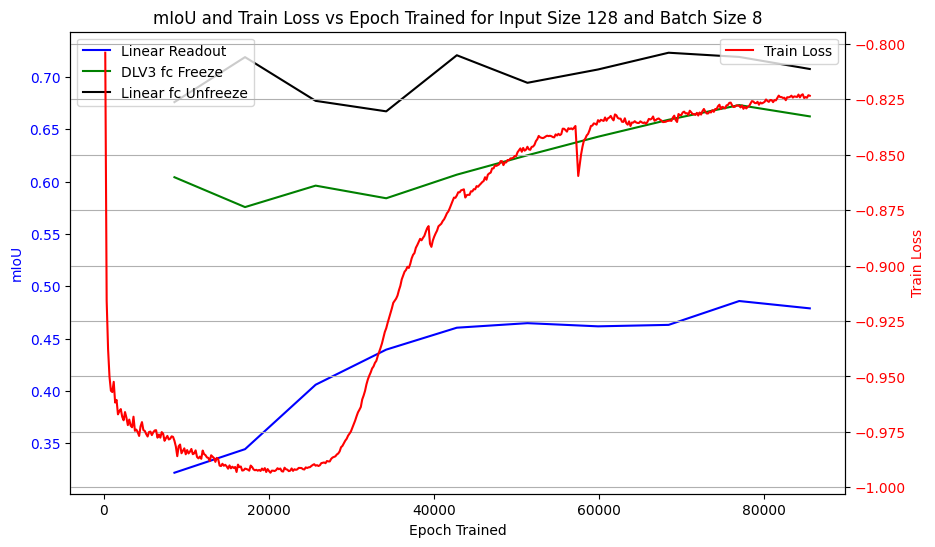

Combination: 256-8
Max mIoU: 0.5245
Max Freeze mIoU: 0.6867


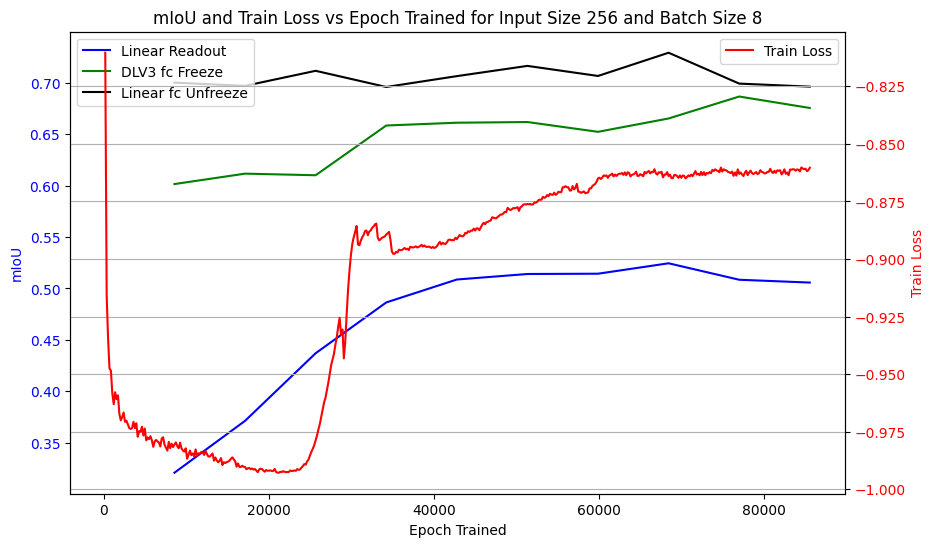

Combination: 512-8
Max mIoU: 0.5195
Max Freeze mIoU: 0.6630


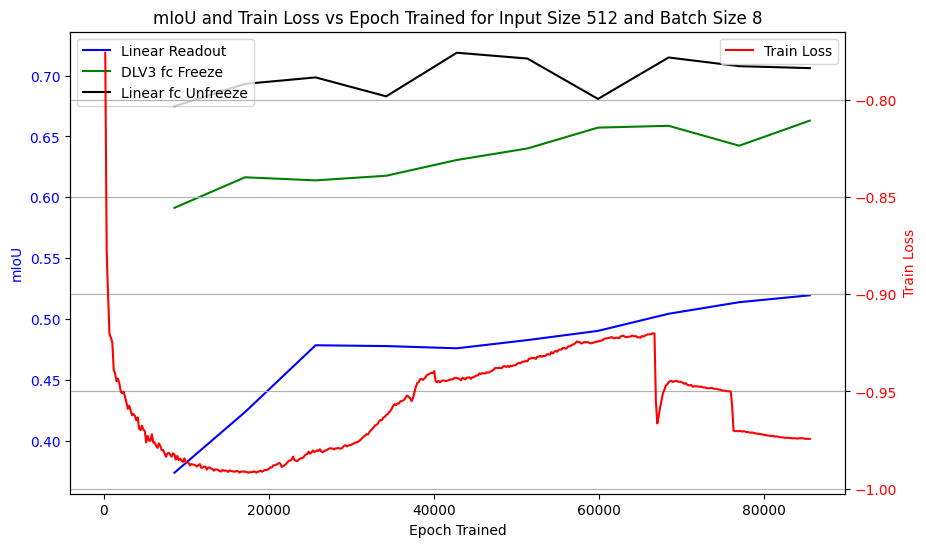

Combination: 512-14
Max mIoU: 0.5388
Max Freeze mIoU: 0.6517


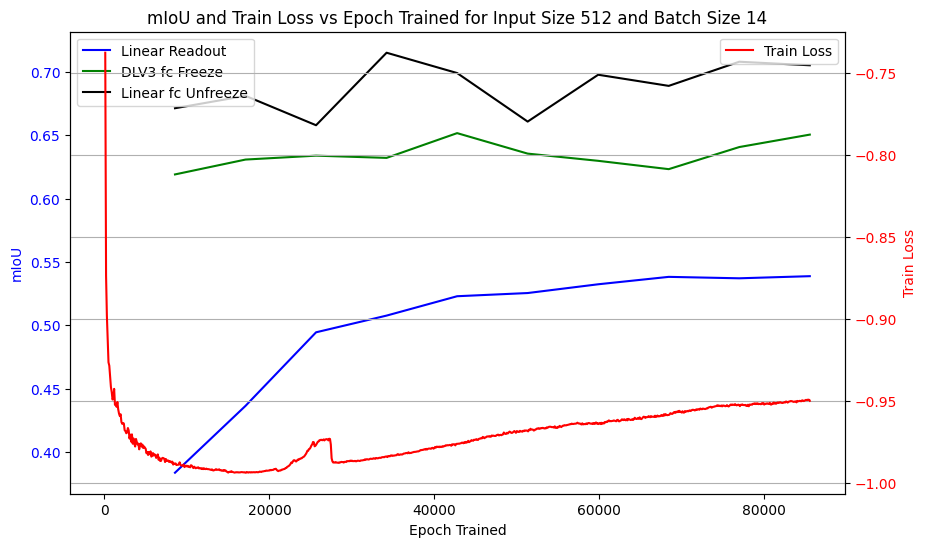

Combination: 128-128
Max mIoU: 0.5492
Max Freeze mIoU: 0.6696


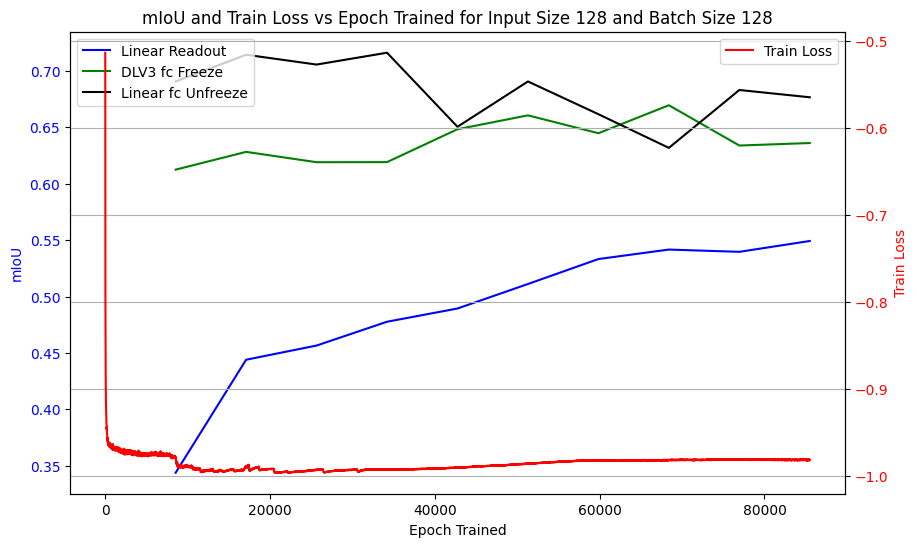

Combination: 256-32
Max mIoU: 0.5443
Max Freeze mIoU: 0.6708


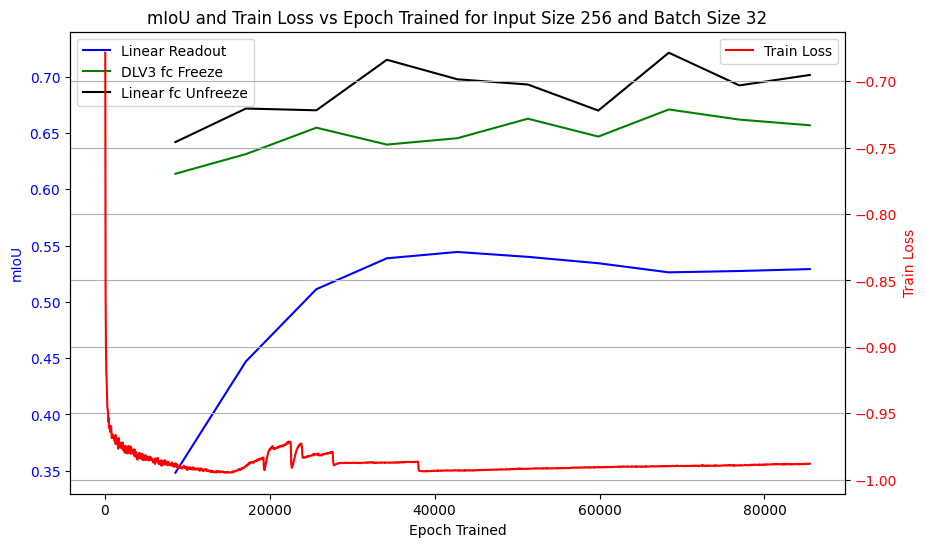

Combination: 256-54
Max mIoU: 0.5440
Max Freeze mIoU: 0.6572


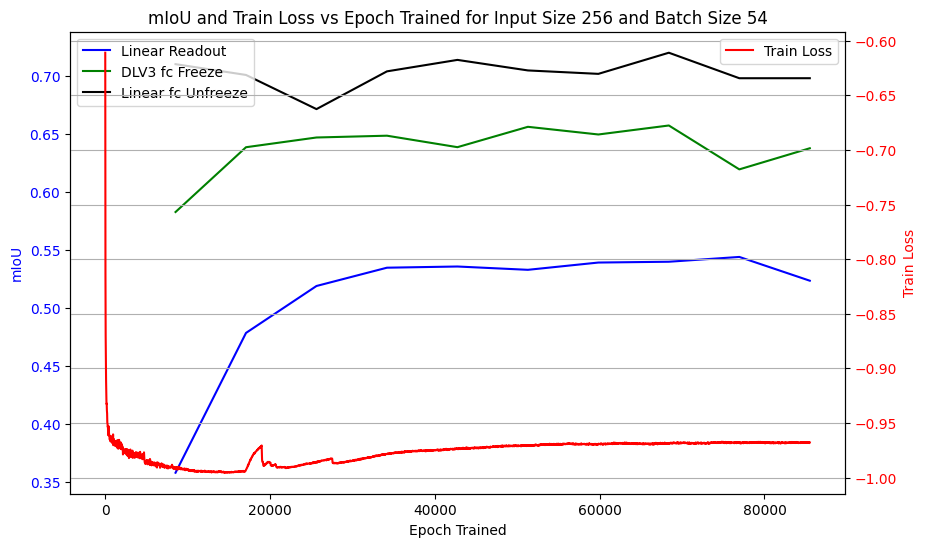

In [24]:
import matplotlib.pyplot as plt

# Filter the dataframe for the combinations
combinations_to_plot = df_merged['combination'].unique()
output_df = pd.DataFrame(columns=['linear_readout_mIoU', 'freeze_mIoU', 'unfreeze_mIoU'])

# Iterate through each combination and plot the graphs
for combination in combinations_to_plot:
    group = df_merged[df_merged['combination'] == combination].sort_values(by='epoch_trained')
    max_values = {
        'linear_readout_mIoU': group['mIoU'].max(),
        'freeze_mIoU': group['freeze_mIoU'].max(),
        'unfreeze_mIoU': group['unfreeze_mIoU'].max(),
        'combination': f"{group['input_size'].iloc[0]}-{group['batch_size'].iloc[0]}"
    }
    output_df = pd.concat([output_df, pd.DataFrame([max_values])], ignore_index=True)
    loss_curve = pd.read_csv(group['metrics_file_y'].iloc[0])
    # Print the combination name and the maximum values of mIoU and freeze mIoU
    print(f"Combination: {group['input_size'].iloc[0]}-{group['batch_size'].iloc[0]}")
    print(f"Max mIoU: {group['mIoU'].max():.4f}")
    print(f"Max Freeze mIoU: {group['freeze_mIoU'].max():.4f}")
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot mIoU on the primary y-axis
    ax1.plot(group['epoch_trained'], group['mIoU'], label='Linear Readout', marker='', color='blue')
    ax1.plot(group['epoch_trained'], group['freeze_mIoU'], label='DLV3 fc Freeze', marker='', color='green')
    ax1.plot(group['epoch_trained'], group['unfreeze_mIoU'], label='Linear fc Unfreeze', marker='', color='black')
    ax1.set_xlabel('Epoch Trained')
    ax1.set_ylabel('mIoU', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    
    # Plot train_loss on the secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(loss_curve['step'], loss_curve['train_loss'], label='Train Loss', linestyle=None, color='red')
    ax2.set_ylabel('Train Loss', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')
    
    plt.title(f'mIoU and Train Loss vs Epoch Trained for Input Size {group["input_size"].iloc[0]} and Batch Size {group["batch_size"].iloc[0]}')
    plt.grid(True)
    plt.show()


In [25]:
output_df = output_df.sort_values(by='unfreeze_mIoU', ascending=False)
output_df

,linear_readout_mIoU,freeze_mIoU,unfreeze_mIoU,combination
2,0.524465,0.686713,0.729340,256-8
0,0.401797,0.614203,0.725483,64-8
1,0.485903,0.673050,0.723076,128-8
6,0.544283,0.670840,0.721232,256-32
7,0.543975,0.657183,0.719852,256-54
3,0.519516,0.663028,0.718830,512-8
5,0.549243,0.669585,0.716157,128-128
4,0.538796,0.651747,0.715234,512-14
